# Assignment 2 - Sentiment Analysis (Part 2: BERT)

## Importing Libraries

In [ ]:
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from sklearn.metrics import (
    accuracy_score,
    auc,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm
from transformers import BertForSequenceClassification, BertTokenizer


## Loading Datasets

In [10]:
train_path = "./data/sentiment-analysis-dataset/train.csv"
test_path = "./data/sentiment-analysis-dataset/test.csv"

In [11]:
# read the dataset
train_df = pd.read_csv(train_path, encoding="Windows-1252")
train_df.rename(columns={
    "sentiment": "polarity",
}, inplace=True)
train_df = train_df[["text", "polarity"]]

# read the dataset
test_df = pd.read_csv(test_path, encoding="Windows-1252")
test_df.rename(columns={
    "sentiment": "polarity",
}, inplace=True)
test_df = test_df[["text", "polarity"]]

# convert target variables into pytorch tensors
label_map = {"negative": 0, "neutral":1, "positive": 2}

train_df["polarity"] = train_df["polarity"].map(label_map)
test_df["polarity"] = test_df["polarity"].map(label_map)

test_df.head()

,text,polarity
0,Last session of the day http://twitpic.com/67ezh,1.0
1,Shanghai is also really exciting (precisely -...,2.0
2,"Recession hit Veronique Branquinho, she has to...",0.0
3,happy bday!,2.0
4,http://twitpic.com/4w75p - I like it!!,2.0


## Similar Preprocessing as Part 1

In [12]:
before = len(train_df)
train_df.dropna(how="any", inplace=True)
train_df['polarity'] = train_df['polarity'].astype('int') 
print(f"{before - len(train_df)} NaN rows dropped from train.")

before = len(test_df)
test_df.dropna(how="any", inplace=True)
test_df['polarity'] = test_df['polarity'].astype('int') 
print(f"{before - len(test_df)} NaN rows dropped from test.")

1 NaN rows dropped from train.
1281 NaN rows dropped from test.


In [13]:
# Slight changes on the preprocessing as the tokenizer will do the tokenization

def text_preprocess(text):
    # Check if the text is a string
    if not isinstance(text, str):
        raise ValueError("Should be a str")

    # Remove urls
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    return text

In [ ]:
#apply the text_preprocess to dataframes
train_df["text_preprocessed"] = train_df["text"].apply(text_preprocess)
test_df["text_preprocessed"] = test_df["text"].apply(text_preprocess)

## BERT Base Uncased

We load the BERT model.

In [15]:
model_name = 'bert-base-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name, num_labels=3, ignore_mismatched_sizes=True)

'(ProtocolError('Connection aborted.', ConnectionResetError(10054, 'An existing connection was forcibly closed by the remote host', None, 10054, None)), '(Request ID: fa08b516-7979-471c-b8a7-02b66f171df3)')' thrown while requesting HEAD https://huggingface.co/bert-base-uncased/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


We freeze the model except for the output layer of each head and the classifier layer of the model.

In [16]:
for param in model.parameters():
    param.requires_grad = False

for layer in model.bert.encoder.layer:
    for param in layer.output.parameters():
        param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

We train only 25% of the model, although training 12% have shown to be enough, as we will discuss in the final section.

In [17]:
# Print trainable params summary
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {trainable_params} / {total_params} ({100 * trainable_params/total_params:.2f}%)")

Trainable params: 28341507 / 109484547 (25.89%)


## Dataset Preparation

In [18]:
class CustomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts.iloc[idx])
        label = self.labels.iloc[idx]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            return_token_type_ids=False,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'label': torch.tensor(label, dtype=torch.long)
        }


In [ ]:
# Set maximum sequence length
MAX_LEN = 64

In [20]:
# Create DataLoaders for train and val sets
train_dataset = CustomDataset(train_df['text_preprocessed'], train_df['polarity'], tokenizer, MAX_LEN)
test_dataset = CustomDataset(test_df['text_preprocessed'], test_df['polarity'], tokenizer, MAX_LEN)

## Model Fine-tuning

In [ ]:
# Define the optimizer
lr = 2e-5
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [ ]:
# Training Params
# We define the same parameters as (part 1)
num_epochs = 30  # Number of epochs
max_patience = 5  # Maximum epochs to wait for improvement
batch_size = 16

In [22]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [23]:
# Training loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [ ]:
losses = []  # List to store the average train loss per epoch
val_losses = []  # List to store the average validation loss per epoch
best_val_loss = float('inf')  # Initialize the best validation loss to infinity
best_epoch = 0  # Epoch with the best validation loss
patience = 0


for epoch in range(num_epochs):
    model.train()
    total_train_loss = 0
    total_val_loss = 0

    # Training
    train_loop = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{num_epochs} [Training]", leave=True)

    for batch in train_loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        avg_train_loss = total_train_loss / (train_loop.n + 1)

        # Update the postfix to show the current average training loss
        train_loop.set_postfix(train_loss=avg_train_loss)

    losses.append(avg_train_loss)

    # Validation
    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(test_loader)

    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch + 1}/{num_epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}")
    
    # Check if the current validation loss is the lowest; if so, save the model
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch
        torch.save(model.state_dict(), 'best_bert_model.pth')  # Save the best model
        patience = 0
    else:
        patience += 1
    
    if patience >= max_patience:
        print(f'Early stopped at {epoch+1}')
        break  # Stop training

print(f'Lowest Validation Loss: {best_val_loss:.4f} at Epoch {best_epoch + 1}')

Epoch 1/10 [Training]: 100%|██████████| 1718/1718 [00:45<00:00, 37.49it/s, train_loss=0.634]


Epoch 1/10, Training Loss: 0.6335, Validation Loss: 0.5426


Epoch 2/10 [Training]: 100%|██████████| 1718/1718 [00:45<00:00, 38.16it/s, train_loss=0.49] 


Epoch 2/10, Training Loss: 0.4905, Validation Loss: 0.5077


Epoch 3/10 [Training]: 100%|██████████| 1718/1718 [00:45<00:00, 38.15it/s, train_loss=0.43] 


...

Epoch 6/10, Training Loss: 0.2597, Validation Loss: 0.6021


Epoch 7/10 [Training]: 100%|██████████| 1718/1718 [00:45<00:00, 38.11it/s, train_loss=0.206]


Epoch 7/10, Training Loss: 0.2059, Validation Loss: 0.6774


Epoch 8/10 [Training]: 100%|██████████| 1718/1718 [00:45<00:00, 38.10it/s, train_loss=0.169]


Epoch 8/10, Training Loss: 0.1689, Validation Loss: 0.7778
Early stopped at 8
Lowest Validation Loss: 0.4989 at Epoch 3


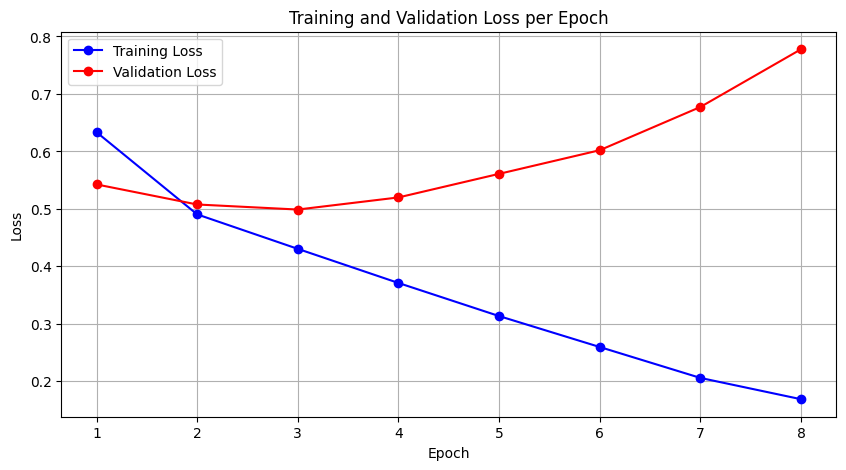

In [26]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, (len(losses)+1)), losses, 'bo-', label='Training Loss')
plt.plot(range(1, (len(losses)+1)), val_losses, 'ro-', label='Validation Loss')
plt.title('Training and Validation Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

## Model Evaluation

In [24]:
def compute_metrics_from_preds(labels, preds):
    acc = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="weighted", zero_division=0)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

In [ ]:
# Load saved weights
best_model_path = "best_bert_model.pth"
model.load_state_dict(torch.load(best_model_path))
model.to(device)

In [ ]:
model.eval()
all_preds = []
all_labels = []
all_proba = [] # List to store probabilities

val_loss = 0.0
val_steps = 0

with torch.no_grad():
    val_iter = tqdm(test_loader, leave=True)
    for batch in val_iter:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        logits = outputs.logits

        val_loss += loss.item()
        val_steps += 1

        # Get probabilities from logits using softmax
        probabilities = F.softmax(logits, dim=1)
        all_proba.extend(probabilities.detach().cpu().numpy().tolist())

        preds = torch.argmax(logits, dim=1).detach().cpu().numpy()
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.detach().cpu().numpy().tolist())

        val_iter.set_postfix(val_loss=f"{(val_loss/val_steps):.4f}")

metrics = compute_metrics_from_preds(all_labels, all_preds)

100%|██████████| 221/221 [00:03<00:00, 71.75it/s, val_loss=0.4989]


In [29]:
metrics

{'accuracy': 0.7925863044708545,
 'precision': 0.7967078048489535,
 'recall': 0.7925863044708545,
 'f1': 0.7935035916328014}

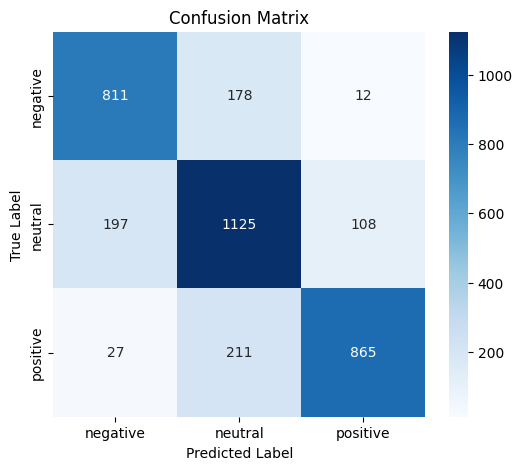

In [30]:
cm = confusion_matrix(all_labels, all_preds)
labels = ["negative", "neutral", "positive"]

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Macro-averaged One-vs-Rest ROC AUC score: 0.93


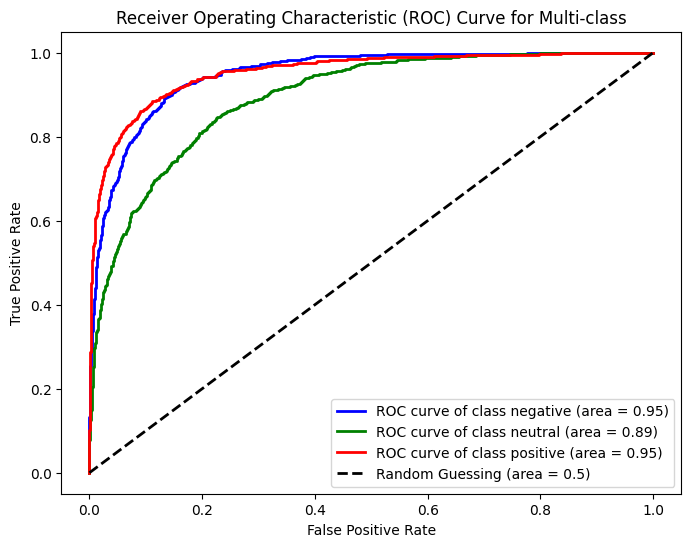

In [ ]:
# Convert lists to numpy arrays
# Note: all_proba should be converted once after the loop finishes.
all_labels = np.array(all_labels)
all_proba = np.array(all_proba) # Make sure this line runs

# Define the labels
labels = ["negative", "neutral", "positive"]
n_classes = len(labels)

# Binarize the true labels for the one-vs-rest strategy
y_true_bin = label_binarize(all_labels, classes=range(n_classes))

# Ensure the binarized labels are also a NumPy array for consistent indexing
# (label_binarize generally returns a NumPy array or sparse matrix, 
# but making sure is safer)
if not isinstance(y_true_bin, np.ndarray):
    y_true_bin = np.array(y_true_bin)

# Compute ROC curve and AUC for each class
fpr = {}
tpr = {}
roc_auc = {}
for i in range(n_classes):
    # This slicing now works because y_true_bin and all_proba are numpy arrays
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], all_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plotting the ROC curves
plt.figure(figsize=(8, 6))
colors = ['blue', 'green', 'red'] # Customize colors as needed

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors[i], lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'.format(labels[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guessing (area = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Multi-class')
plt.legend(loc="lower right")

# Calculate macro-averaged ROC AUC score (overall metric)
macro_roc_auc_ovr = roc_auc_score(all_labels, all_proba, multi_class="ovr", average="macro")
print(f"Macro-averaged One-vs-Rest ROC AUC score: {macro_roc_auc_ovr:.2f}")

## Comparative Study & Conclusion

### **1. Metrics Overview**

| Model              | Accuracy | Precision<sup>\*</sup> | Recall<sup>\*</sup> | F1 Score<sup>\*</sup> | ROC AUC<sup>\*</sup><span style="font-family: Times, serif;"><sup>†</sup></span> |
| ------------------ | -------- | ---------------------- | ------------------- | --------------------- | -------------------------------------------------------------------------------- |
| Bi-RNN             | 50.8%    | 51.9%                  | 50.8%               | 49.2%                 | 0.68                                                                             |
| Bi-GRU             | 66.2%    | 66.9%                  | 66.2%               | 66.1%                 | 0.83                                                                             |
| Bi-LSTM            | 65.0%    | 67.3%                  | 65.0%               | 65.0%                 | 0.83                                                                             |
| BERT<sup>(1)</sup> | 67.2%    | 67.2%                  | 67.2%               | 67.2%                 | 0.84                                                                             |
| BERT<sup>(2)</sup> | 78.3%    | 78.5%                  | 78.3%               | 78.3%                 | 0.93                                                                             |
| BERT<sup>(3)</sup> | 79.3%    | 79.7%                  | 79.3%               | 79.4%                 | 0.93                                                                             |

<br>

> * Validation/Test metrics  
> <span style="font-family: Times, serif;">†</span> Macro-averaged One-vs-Rest (OvR) ROC AUC score  
> **(1)**: Only the classifier layer was fine-tuned  
> **(2)**: Half of the head outputs & classifier layers were fine-tuned (~12% of the model)  
> **(3)**: All head outputs & classifier layers were fine-tuned (~25% of the model)

---

### **2. Confusion Matrix Analysis**

To complement the metric-based evaluation, we present the confusion matrices for each model. These matrices provide deeper insight into how well each model distinguishes between the three sentiment classes: **Negative (NEG)**, **Neutral (NEU)**, and **Positive (POS)**.

#### 🔍 Observations:

- **Bi-RNN** shows significant confusion between **NEG** and **NEU**, with a large number of NEG samples misclassified as NEU. This aligns with its low overall performance and suggests poor feature representation.
  
- **Bi-GRU** and **Bi-LSTM** improve class separation, especially for **POS**, but still show moderate confusion between **NEG** and **NEU**, indicating limitations in capturing nuanced sentiment transitions.

- **BERT** demonstrates **strong diagonal dominance**, especially in the **NEG** and **POS** classes, with minimal misclassifications. This reflects its superior contextual understanding and confirms the quantitative metrics.

#### 📊 Confusion Matrices

<table style="border-collapse: collapse; table-layout: auto; text-align: center; border: 0px solid black;">
<tr>
    <!-- Top-left: Bi-RNN -->
    <td>
<table style="border-collapse: collapse; table-layout: fixed; text-align: center; width: 300px;">
    <caption style="font-weight: bold; margin-bottom: 10px;">Confusion Matrix (Bi-RNN)</caption>
    <thead>
        <tr>
            <th style="border: 1px solid #ccc; width: 75px; text-align: center; height: 75px;"></th>
            <th style="border: 1px solid #ccc; width: 75px; text-align: center; ">NE&#x0302G</th>
            <th style="border: 1px solid #ccc; width: 75px; text-align: center; ">NE&#x0302U</th>
            <th style="border: 1px solid #ccc; width: 75px; text-align: center; ">PO&#x0302S</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="border: 1px solid #ccc; height: 75px;"><strong>NEG</strong></td>
            <td style="background-color:#cfe2f3;color:black; height: 75px;">264</td>
            <td style="background-color:#6fa8dc;color:white; height: 75px;">628</td>
            <td style="background-color:#f2f6fc;color:black; height: 75px;">109</td>
        </tr>
        <tr>
            <td style="border: 1px solid #ccc; height: 75px;"><strong>NEU</strong></td>
            <td style="background-color:#d9e7f5;color:black; height: 75px;">204</td>
            <td style="background-color:#08306b;color:white; height: 75px;">1019</td>
            <td style="background-color:#d9e7f5;color:black; height: 75px;">207</td>
        </tr>
        <tr>
            <td style="border: 1px solid #ccc; height: 75px;"><strong>POS</strong></td>
            <td style="background-color:#f2f6fc;color:black; height: 75px;">88</td>
            <td style="background-color:#6fa8dc;color:white; height: 75px;">504</td>
            <td style="background-color:#6fa8dc;color:white; height: 75px;">511</td>
        </tr>
    </tbody>
</table>
    </td>
    <!-- Top-right: Bi-GRU -->
    <td>
<table style="border-collapse: collapse; table-layout: fixed; text-align: center; width: 300px;">
        <caption style="font-weight: bold;; margin-bottom: 10px;">Confusion Matrix (Bi-GRU)</caption>
            <thead>
        <tr>
            <th style=" width: 75px;border: 1px solid #ccc; width: 75px; text-align: center; height: 75px;"></th>
            <th style=" width: 75px;border: 1px solid #ccc; width: 75px; text-align: center; height: 75px;">NE&#x0302G</th>
            <th style=" width: 75px;border: 1px solid #ccc; width: 75px; text-align: center; height: 75px;">NE&#x0302U</th>
            <th style=" width: 75px;border: 1px solid #ccc; width: 75px; text-align: center; height: 75px;">PO&#x0302S</th>
        </tr>
    </thead>
        <tbody>
          <tr>
            <td style=" width: 75px;border: 1px solid #ccc;height: 75px; width: 75px;"><strong>NEG</strong></td>
            <td style=" width: 75px;background-color:#6fa8dc;color:white;height: 75px; width: 75px;">559</td>
            <td style=" width: 75px;background-color:#cfe2f3;color:black;height: 75px;">381</td>
            <td style=" width: 75px;background-color:#f2f6fc;color:black;height: 75px;">61</td>
          </tr>
          <tr>
            <td style=" width: 75px;border: 1px solid #ccc;height: 75px;"><strong>NEU</strong></td>
            <td style=" width: 75px;background-color:#d9e7f5;color:black;height: 75px;">208</td>
            <td style=" width: 75px;background-color:#08306b;color:white;height: 75px;">1029</td>
            <td style=" width: 75px;background-color:#d9e7f5;color:black;height: 75px;">193</td>
          </tr>
          <tr>
            <td style=" width: 75px;border: 1px solid #ccc;height: 75px;"><strong>POS</strong></td>
            <td style=" width: 75px;background-color:#f2f6fc;color:black;">57</td>
            <td style=" width: 75px;background-color:#cfe2f3;color:black;">296</td>
            <td style=" width: 75px;background-color:#6fa8dc;color:white;">750</td>
          </tr>
        </tbody>
      </table>
    </td>

  </tr>

  <tr>
    <!-- Bottom-left: Bi-LSTM -->
    <td>
<table style="border-collapse: collapse; table-layout: fixed; text-align: center; width: 300px;">
    <caption style="font-weight: bold; margin-bottom: 10px;">Confusion Matrix (Bi-LSTM)</caption>
    <thead>
        <tr>
            <th style="border: 1px solid #ccc; width: 75px; text-align: center; height: 75px; width: 75px;"></th>
            <th style="border: 1px solid #ccc; width: 75px; text-align: center; height: 75px; width: 75px;">NE&#x0302G</th>
            <th style="border: 1px solid #ccc; width: 75px; text-align: center; height: 75px; width: 75px;">NE&#x0302U</th>
            <th style="border: 1px solid #ccc; width: 75px; text-align: center; height: 75px; width: 75px;">PO&#x0302S</th>
        </tr>
    </thead>
        <tbody>
          <tr>
            <td style="border: 1px solid #ccc;height: 75px;"><strong>NEG</strong></td>
            <td style="background-color:#6fa8dc;color:white;">547</td>
            <td style="background-color:#cfe2f3;color:black;">423</td>
            <td style="background-color:#f2f6fc;color:black;">31</td>
          </tr>
          <tr>
            <td style="border: 1px solid #ccc;height: 75px;"><strong>NEU</strong></td>
            <td style="background-color:#d9e7f5;color:black;">224</td>
            <td style="background-color:#08306b;color:white;">1085</td>
            <td style="background-color:#d9e7f5;color:black;">121</td>
          </tr>
          <tr>
            <td style="border: 1px solid #ccc;height: 75px;"><strong>POS</strong></td>
            <td style="background-color:#f2f6fc;color:black;">57</td>
            <td style="background-color:#cfe2f3;color:black;">380</td>
            <td style="background-color:#6fa8dc;color:white;">666</td>
          </tr>
        </tbody>
      </table>
    </td>
    <!-- Bottom-right: BERT -->
    <td>
<table style="border-collapse: collapse; table-layout: fixed; text-align: center; width: 300px;">
    <caption style="font-weight: bold;; margin-bottom: 10px;">Confusion Matrix (BERT)</caption>
    <thead>
        <tr>
            <th style="border: 1px solid #ccc; width: 75px; text-align: center; height: 75px;"></th>
            <th style="border: 1px solid #ccc; width: 75px; text-align: center; height: 75px;">NE&#x0302G</th>
            <th style="border: 1px solid #ccc; width: 75px; text-align: center; height: 75px;">NE&#x0302U</th>
            <th style="border: 1px solid #ccc; width: 75px; text-align: center; height: 75px;">PO&#x0302S</th>
        </tr>
    </thead>
        <tbody>
          <tr>
            <td style="border: 1px solid #ccc;height: 75px;"><strong>NEG</strong></td>
            <td style="background-color:#2171b5;color:white;">811</td>
            <td style="background-color:#cfe2f3;color:black;">178</td>
            <td style="background-color:#f2f6fc;color:black;">12</td>
          </tr>
          <tr>
            <td style="border: 1px solid #ccc;height: 75px;"><strong>NEU</strong></td>
            <td style="background-color:#d9e7f5;color:black;">197</td>
            <td style="background-color:#08306b;color:white;">1125</td>
            <td style="background-color:#d9e7f5;color:black;">108</td>
          </tr>
          <tr>
            <td style="border: 1px solid #ccc;height: 75px;"><strong>POS</strong></td>
            <td style="background-color:#f2f6fc;color:black;">27</td>
            <td style="background-color:#cfe2f3;color:black;">211</td>
            <td style="background-color:#2171b5;color:white;">865</td>
          </tr>
        </tbody>
      </table>
    </td>

  </tr>
</table>

---

### **3. Final Interpretation & Conclusion**

The confusion matrices and performance metrics collectively reveal the strengths and limitations of each model:

- **Bi-RNN** struggled to learn meaningful representations. Its predictions were heavily biased toward the **Neutral** class, which had a slightly higher representation in the dataset. This indicates that the model failed to generalize and instead leaned toward frequency-based guessing, resulting in poor performance on both **Negative** and **Positive** classes.

- **Bi-GRU** and **Bi-LSTM** showed noticeable improvements. Both models were able to better capture the **Negative** and **Positive** sentiments, though they still exhibited a mild bias toward the **Neutral** class. Their confusion matrices reflect more balanced predictions, but with some overlap between adjacent sentiment classes.

- **BERT** clearly outperformed all other models. With nearly **80% accuracy** and a **balanced F1 score**, it demonstrated strong generalization across all classes. The confusion matrix shows minimal misclassification and a well-distributed prediction pattern, indicating that BERT was **less biased** and more capable of understanding contextual nuances in the data.

---

### ✅ **Deployment Recommendation**

While fine-tuning depth affects training cost, it is **not the primary concern for deployment**. In production, **inference speed, memory footprint, and prediction accuracy** are the key factors.

- **BERT<sup>(3)<sup>**, despite requiring more extensive fine-tuning (~25% of the model), offers the **best inference performance** with the highest accuracy (79.3%) and balanced F1 score. Since fine-tuning is done infrequently, the **runtime cost of inference remains the same** across all BERT variants. Therefore, **BERT<sup>(3)<sup>** is the most suitable candidate for deployment in both high-performance and general-purpose environments.

- **Bi-GRU and Bi-LSTM** could be viable for **edge devices or latency-critical applications**, but their lower accuracy and bias toward the Neutral class make them less ideal for tasks requiring high precision across all sentiment classes.